<a href="https://colab.research.google.com/github/abeeraz379/Zillow-Data_Time-Series-Forecasting/blob/main/Time_series__belt_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# zillow_home_values-zipcode
- Data Link : https://drive.google.com/file/d/1AvW12feuwhWJY4fSSIUt5sOd3d2sh_nv/view?usp=sharing

# PART 1

## load and inspect data

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 35.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pmdarima as pm
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.tsa.api as tsa
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs, nsdiffs

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/Exams/zillow_home_values-zipcode.csv")
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,...,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,...,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,...,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,...,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,...,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,...,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27442 entries, 0 to 27441
Columns: 284 entries, RegionID to 30112022
dtypes: float64(275), int64(3), object(6)
memory usage: 59.5+ MB


In [ ]:
df.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       'State', 'City', 'Metro', 'CountyName', '31012000',
       ...
       '28022022', '31032022', '30042022', '31052022', '30062022', '31072022',
       '31082022', '30092022', '31102022', '30112022'],
      dtype='object', length=284)

## Melt the wide-form data into a long-form time series.

In [ ]:
melted = pd.melt(df,id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName']
     ,var_name="Date",
     value_name="Home Value")
melted

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,31012000,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,31012000,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,31012000,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,275983.0
...,...,...,...,...,...,...,...,...,...,...,...
7546545,80190,30657,50160,zip,IA,IA,Martensdale,"Des Moines-West Des Moines, IA",Warren County,30112022,193591.0
7546546,65355,30657,18081,zip,PA,PA,Hellertown,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",Bucks County,30112022,376523.0
7546547,82217,30657,55366,zip,MN,MN,NaN,NaN,Sibley County,30112022,110082.0
7546548,80581,30657,51009,zip,IA,IA,Calumet,NaN,O Brien County,30112022,75810.0


In [ ]:
melted["Date"] = pd.to_datetime(melted["Date"], format="%d%m%Y")

In [ ]:

melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,2000-01-31,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,2000-01-31,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,275983.0


In [ ]:
melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7546550 entries, 0 to 7546549
Data columns (total 11 columns):
 #   Column      Dtype         
---  ------      -----         
 0   RegionID    int64         
 1   SizeRank    int64         
 2   RegionName  int64         
 3   RegionType  object        
 4   StateName   object        
 5   State       object        
 6   City        object        
 7   Metro       object        
 8   CountyName  object        
 9   Date        datetime64[ns]
 10  Home Value  float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 633.3+ MB


## Prepare a copy of the data, which you will be saving for tableau

In [ ]:
states_to_keep = ["CA", "WA", "OR", "AZ", "NV"]
melted["Year"] = melted["Date"].dt.year
df_filtered = melted[(melted["State"].isin(states_to_keep)) &
                 (melted["Year"].between(2009, 2020))]

In [ ]:
output_path = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/Exams/data-for-tableau.csv"
df_filtered.to_csv(output_path, index=False)

In [ ]:
melted = melted.set_index("Date").sort_index()

## Resample the home values, grouped by states, to a yearly frequency (based on the beginning of the calendar year)

/tmp/ipykernel_1282/4117817867.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


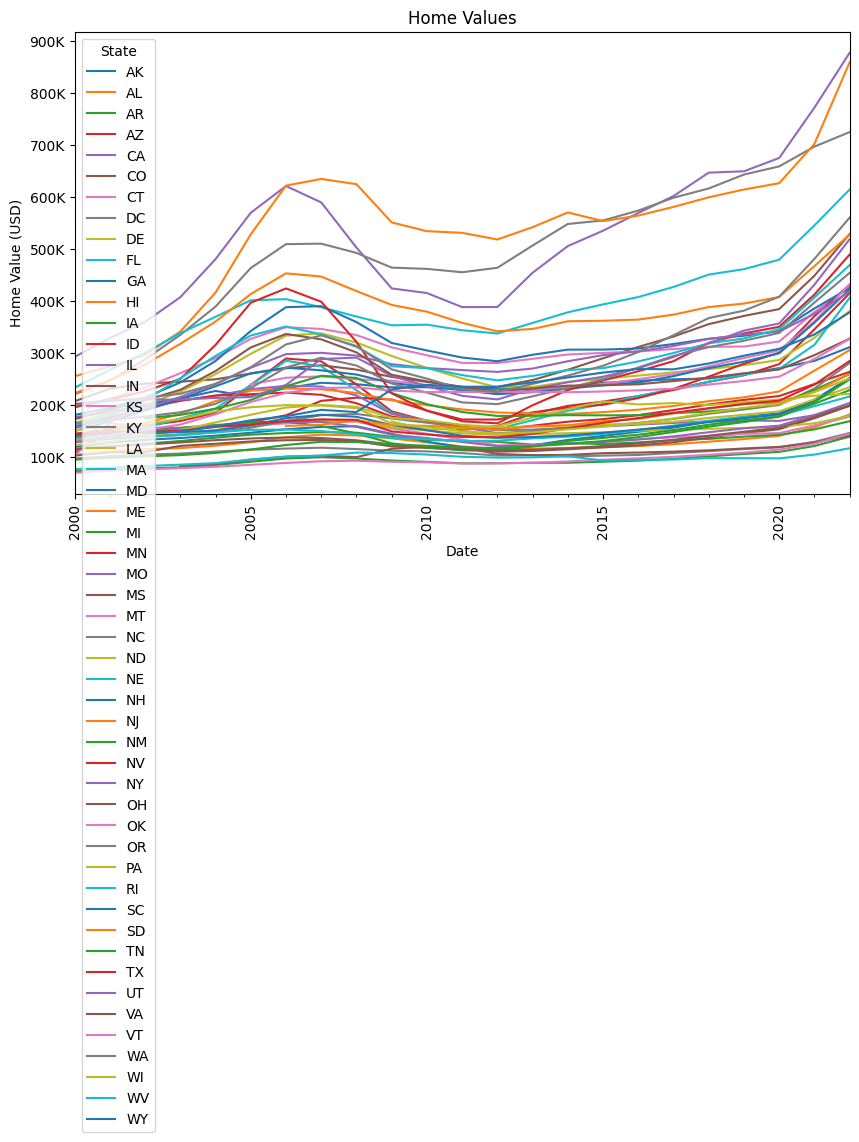

In [ ]:
df_plot = (
    melted
    .groupby(["State"])["Home Value"]
    .resample("YS")
    .mean()
    .unstack("State")
)
fig, ax = plt.subplots(figsize=(10, 6))
df_plot.plot(ax=ax)

ax.set_title("Home Values")
ax.set_xlabel("Date")
ax.set_ylabel("Home Value (USD)")

def format_k(x, pos):
    return f"{int(x/1000)}K"

ax.yaxis.set_major_formatter(FuncFormatter(format_k))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# PART 2

## Custom Functions

In [ ]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [ ]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = np.sqrt(mse)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [ ]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [ ]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

## Filter the data and transform the data to obtain a time series of the mean value of home prices for the month

In [ ]:
melted_or = melted.loc[melted["State"] == "OR"]
melted_or = melted_or.sort_index()
melted_or = melted_or.loc["2000-01-31":"2018-12-31"]
ts_or_monthly = melted_or["Home Value"].resample("M").mean()


/tmp/ipykernel_1282/1188761290.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts_or_monthly = melted_or["Home Value"].resample("M").mean()


In [ ]:
ts_or_monthly.head()

,Home Value
Date,
2000-01-31,162508.613445
2000-02-29,162913.172269
2000-03-31,163011.125523
2000-04-30,163541.908333
2000-05-31,164176.420833


## Check for and address null values.

In [ ]:
ts_or_monthly = ts_or_monthly.interpolate("time")

In [ ]:
ts_or_monthly.isna().sum()

np.int64(0)

## Seasonality

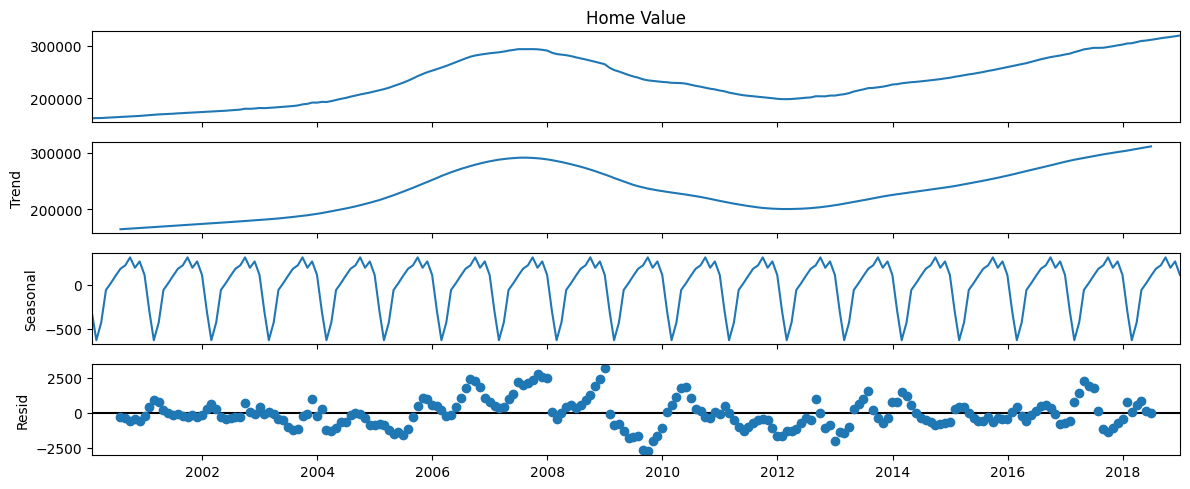

In [ ]:
decomp = seasonal_decompose(ts_or_monthly, model="additive", period=12)
fig = decomp.plot()
fig.set_size_inches(12, 5)
fig.tight_layout()
plt.show()

In [ ]:
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()

variation = ts_or_monthly.max() - ts_or_monthly.min()

print(
    f"The seasonal component is {seasonal_delta:.2f} "
    f"which is ~{seasonal_delta/variation*100:.2f}% "
    f"of the variation in time series."
)

The seasonal component is 948.43 which is ~0.61% of the variation in time series.


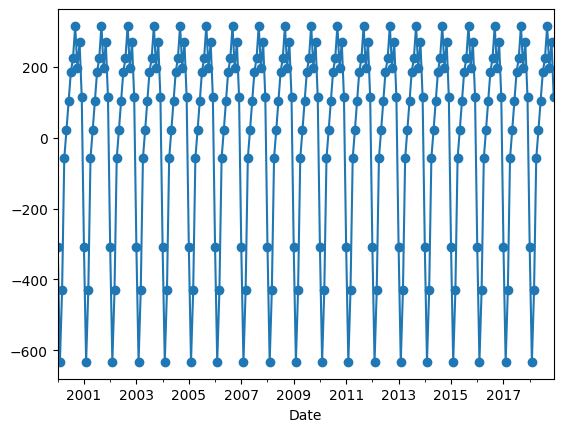

In [ ]:
seasonal = decomp.seasonal
ax = seasonal.loc['2000': '2018'].plot(marker = 'o')

## stationarity

In [ ]:
get_adfuller_results(ts_or_monthly)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.786015,3,224,0.387427,0.05,False


In [35]:
D = nsdiffs(ts_or_monthly, m = 12)
print (f'D = {D}')
d = ndiffs(ts_or_monthly)
print (f'd = {d}')

D = 0
d = 2


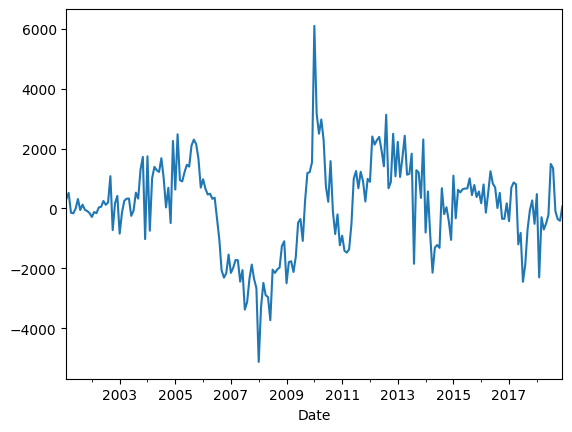

In [36]:
ts_diff = ts_or_monthly.diff().diff(12).dropna()
ts_diff.plot();


## ACF/PACF Plots

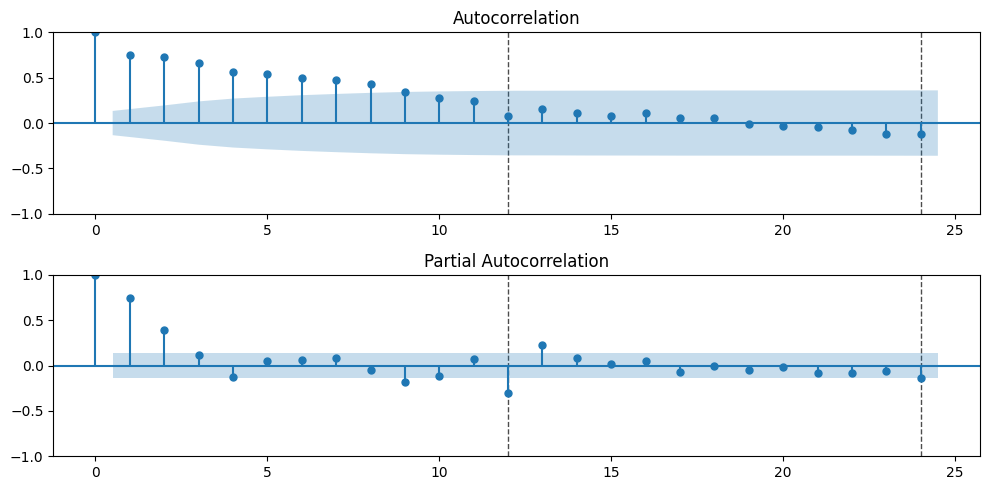

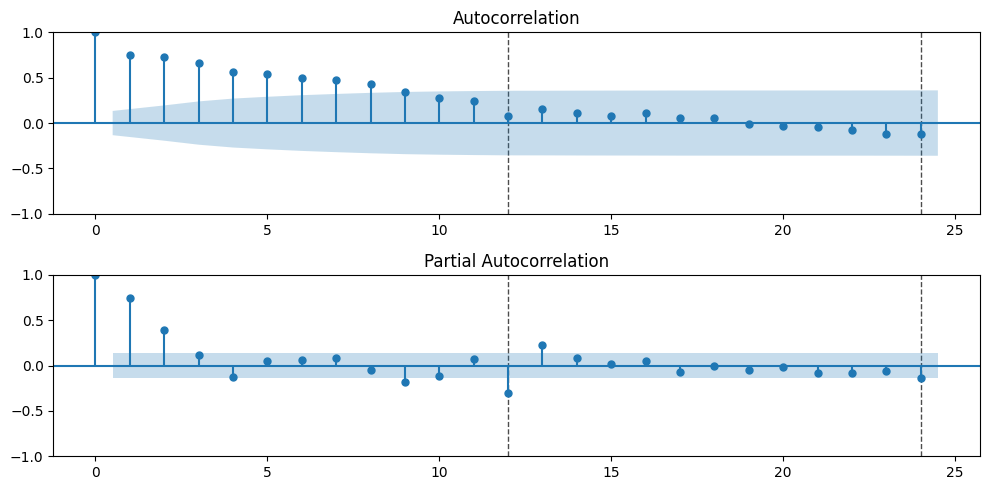

In [40]:
# now look at the acf/pacf of the stationary data
plot_acf_pacf(ts_diff, annotate_seas = True, m = 12, nlags=24)

## Train Test Split

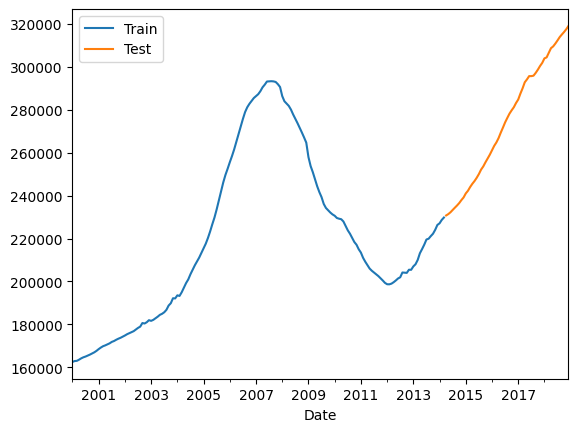

In [39]:
train, test = train_test_split(ts_or_monthly, test_size=.25)
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend()

## Fit initial model

In [41]:
# Orders for non seasonal components
p = 1  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 0  # nonseasonal MA

# Orders for seasonal components
P = 1  # Seasonal AR
D = 0  # Seasonal differencing
Q = 1  # Seasonal MA
m = 12 # Seasonal period

sarima = tsa.ARIMA(train, order = (p,d,q), seasonal_order=(P,D,Q,m)).fit()

# Obtain summary
sarima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                         Home Value   No. Observations:                  171
Model:             ARIMA(1, 2, 0)x(1, 0, [1], 12)   Log Likelihood               -1374.583
Date:                            Sat, 18 Jul 2026   AIC                           2757.166
Time:                                    06:43:43   BIC                           2769.686
Sample:                                01-31-2000   HQIC                          2762.247
                                     - 03-31-2014                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0092      0.015     -0.606      0.545      -0.039       0.021
ar.S.L12       0.0556     12.409      0.004      0.996     -24.265      24.376
ma.S.L12      -0.0493     12.413     -0.004      0.997     -24.378      24.279
sigma2      6.758e+05   4.62e+04     14.628      0.000    5.85e+05    7.66e+05
===================================================================================
Ljung-Box (L1) (Q):                  22.99   Jarque-Bera (JB):               231.13
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.34   Skew:                            -1.12
Prob(H) (two-sided):                  0.28   Kurtosis:                         8.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## diagnostic plots

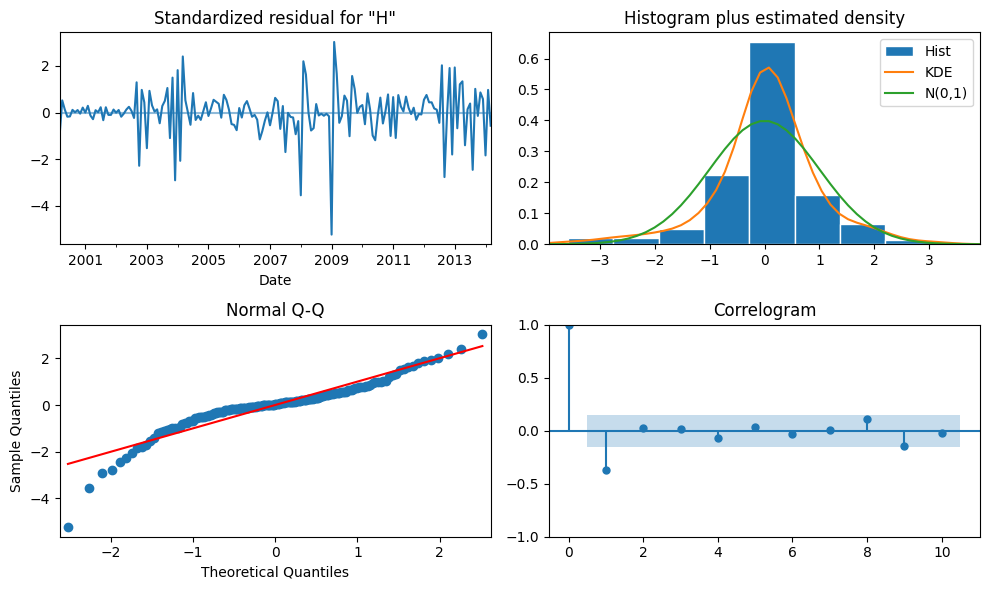

In [42]:
fig = sarima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 12,695.912
- MSE = 251,375,281.012
- RMSE = 15,854.819
- R^2 = 0.680
- MAPE = 4.32%


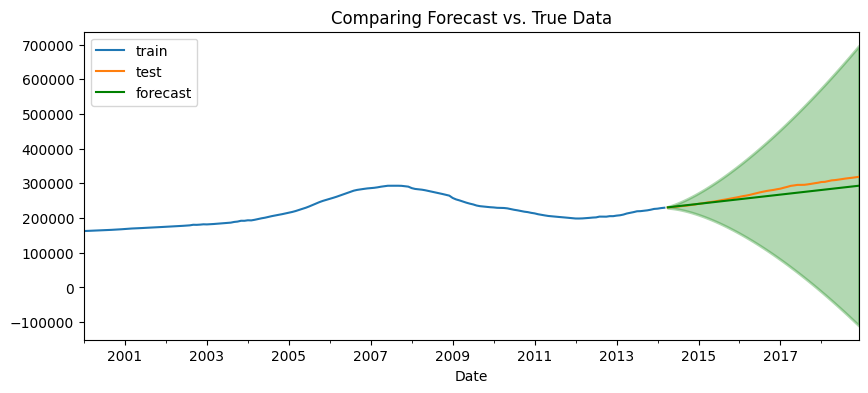

In [43]:
forecast_df = sarima.get_forecast(steps=len(test)).summary_frame()
plot_forecast(train, test, forecast_df);
regression_metrics_ts(test, forecast_df['mean'])

## Auto_Arima

In [44]:
# Default auto_arima will select model based on AIC score
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[12]             : AIC=2763.472, Time=0.89 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=2751.703, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=2756.772, Time=0.07 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=2756.752, Time=0.05 sec
 ARIMA(0,2,0)(1,0,0)[12]             : AIC=2753.523, Time=0.10 sec
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=2753.523, Time=0.08 sec
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=2757.480, Time=0.15 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=2755.005, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=2754.983, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=2754.803, Time=0.11 sec
 ARIMA(0,2,0)(0,0,0)[12] intercept   : AIC=2753.699, Time=0.02 sec

Best model:  ARIMA(0,2,0)(0,0,0)[12]          
Total fit time: 1.549 seconds


In [45]:
# the auto_arima will store our best nonseasonal and seasonal orders separtely
print(auto_model.order)
print(auto_model.seasonal_order)

(0, 2, 0)
(0, 0, 0, 12)


In [46]:
# Obtain summary of the best model from auto_arima
auto_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  171
Model:               SARIMAX(0, 2, 0)   Log Likelihood               -1374.852
Date:                Sat, 18 Jul 2026   AIC                           2751.703
Time:                        06:46:39   BIC                           2754.833
Sample:                    01-31-2000   HQIC                          2752.973
                         - 03-31-2014                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      6.818e+05   3.87e+04     17.628      0.000    6.06e+05    7.58e+05
===================================================================================
Ljung-Box (L1) (Q):                  23.66   Jarque-Bera (JB):               238.70
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.35   Skew:                            -1.12
Prob(H) (two-sided):                  0.26   Kurtosis:                         8.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

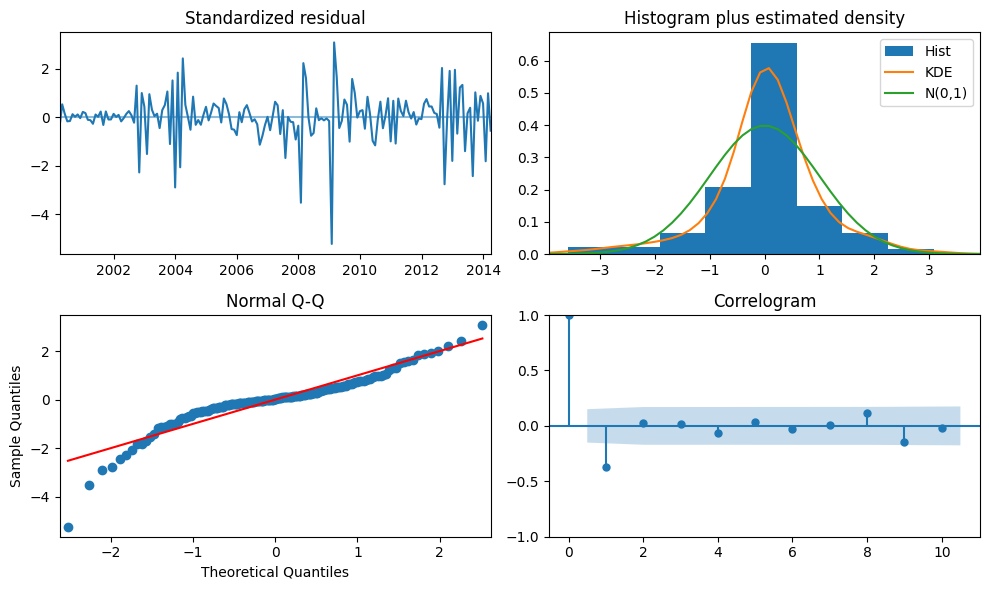

In [47]:
# Obtain diagnostic plots
fig = auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 12,698.096
- MSE = 251,339,539.539
- RMSE = 15,853.692
- R^2 = 0.680
- MAPE = 4.32%


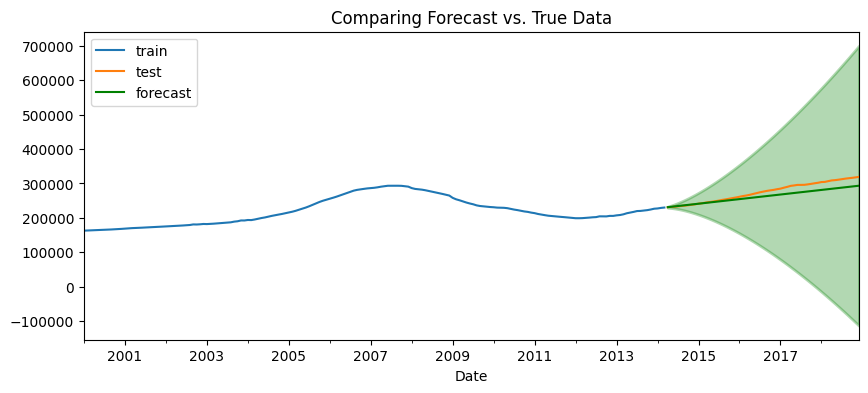

In [48]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(
    train, order=auto_model.order, seasonal_order=auto_model.seasonal_order
).fit()


# Obtain forecast as a dataframe with confidence intervals
forecast_df = auto_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

# Final Result
The 2 models has approximatly the same result with the same MPAE

In [49]:
forecast = sarima.forecast(steps=12)
print(forecast)

2014-04-30    230891.061430
2014-05-31    232008.722542
2014-06-30    233127.223734
2014-07-31    234247.582011
2014-08-31    235355.908334
2014-09-30    236468.773573
2014-10-31    237580.836483
2014-11-30    238697.878464
2014-12-31    239817.335832
2015-01-31    240927.910947
2015-02-28    242043.366283
2015-03-31    243156.236691
Freq: ME, Name: predicted_mean, dtype: float64


In [51]:
predicted_value_12mo = forecast.iloc[-1]
start_cases = forecast.iloc[0]
print(f"Predicted home value in 12 months:{predicted_value_12mo}")

print(f"Cumulative cases in final forecast month: {predicted_value_12mo:,.0f}")

percent_change = ((predicted_value_12mo - start_cases) / start_cases) * 100
print(f"Percent change over 12 months: {percent_change:.1f}%")



Predicted home value in 12 months:243156.23669057724
Cumulative cases in final forecast month: 243,156
Percent change over 12 months: 5.3%


## Summarize forecast

In [52]:
print(f"The forecast predicts {predicted_value_12mo:,.0f} cumulative cases "
f"by the final forecast month, representing a "
f"{percent_change:.1f}% change over the 12‑month forecast period.")

The forecast predicts 243,156 cumulative cases by the final forecast month, representing a 5.3% change over the 12‑month forecast period.


# PART 3

## Tableau Link
https://public.tableau.com/views/Zillowhomevalues/differenceinmedianHomeValueperstate?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link